In [ ]:
import pandas as pd

valores_miles = [
    # 2018
    105350, 73855, 83124, 88620, 86798, 88600,
    80283, 73912, 56700, 72856, 73123, 95473,

    # 2019
    82302, 73353, 86648, 78880, 78629, 79068,
    92577, 95309, 75601, 75886, 75311, 97087,

    # 2020
    86670, 86947, 73015, 60409, 67765, 72486,
    90012, 83563, 80635, 93211, 95770, 96039,

    # 2021
    68854, 79207, 97524, 83501, 90961, 87584,
    98492, 100536, 97476, 100816, 105166, 116195,

    # 2022
    94468, 91472, 121094, 108341, 107909, 104104,
    113137, 109099, 93558, 93843, 98301, 110331,

    # 2023
    91605, 87577, 123440, 106158, 106735, 98759,
    100487, 101061, 91284, 87492, 89997, 89960,

    # 2024 enero-junio
    94726, 83676, 82433, 89413, 74819, 72844
]
df = pd.DataFrame({
    "PERIODO": pd.date_range("2018-01-01", periods=len(valores_miles), freq="MS"),
    "DESCONEXIONES": [x * 1000 for x in valores_miles]
})


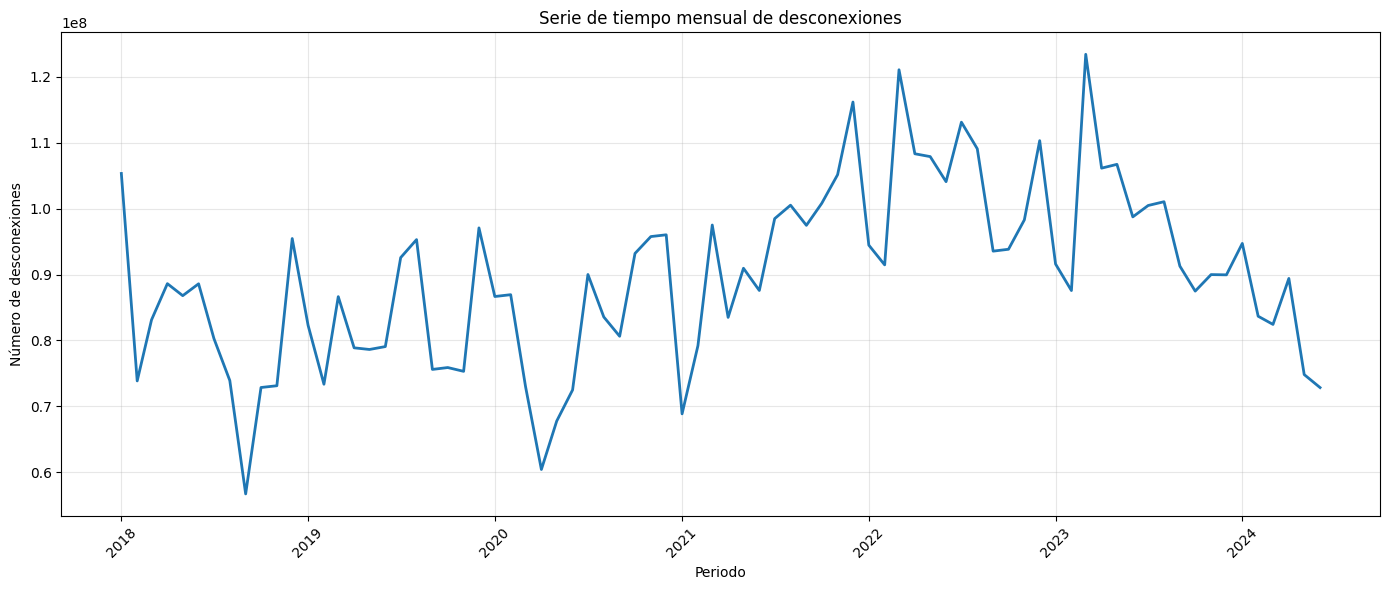

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    df["PERIODO"],
    df["DESCONEXIONES"],
    linewidth=2
)

plt.xlabel("Periodo")
plt.ylabel("Número de desconexiones")
plt.title("Serie de tiempo mensual de desconexiones")

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Redefinir el DataFrame eliminando outliers con el método IQR

Q1 = df["DESCONEXIONES"].quantile(0.25)
Q3 = df["DESCONEXIONES"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df = df[
    (df["DESCONEXIONES"] >= limite_inferior) &
    (df["DESCONEXIONES"] <= limite_superior)
].reset_index(drop=True)

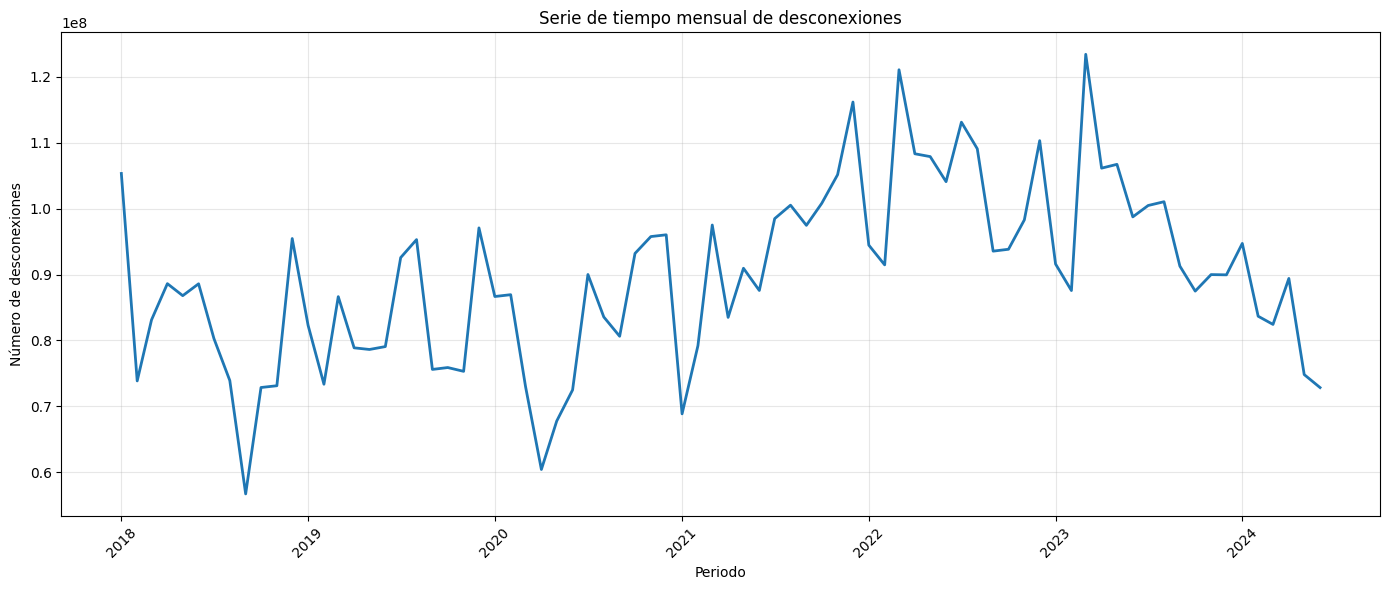

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    df["PERIODO"],
    df["DESCONEXIONES"],
    linewidth=2
)

plt.xlabel("Periodo")
plt.ylabel("Número de desconexiones")
plt.title("Serie de tiempo mensual de desconexiones")

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


INICIALIZACIÓN
P1 inicial  = 12.000000 meses
P2 inicial  = 24.000000 meses
P3 inicial  = 96.000000 meses
rho inicial = 0.999990

Epoch     0 | Loss = 21.535788 | NLL = 21.535774 | Support = 0.000000 | Ridge = 0.000014 | rho = 0.999989 | P = [12.000, 24.000, 95.999]
Epoch   100 | Loss = 17.558841 | NLL = 17.558756 | Support = 0.000000 | Ridge = 0.000086 | rho = 0.999079 | P = [13.043, 21.871, 96.896]
Epoch   200 | Loss = 17.476993 | NLL = 17.476888 | Support = 0.000000 | Ridge = 0.000105 | rho = 0.999006 | P = [16.823, 20.535, 87.766]
Epoch   300 | Loss = 17.448430 | NLL = 17.448318 | Support = 0.000000 | Ridge = 0.000112 | rho = 0.998978 | P = [17.154, 20.697, 78.603]
Epoch   400 | Loss = 17.436851 | NLL = 17.436739 | Support = 0.000000 | Ridge = 0.000113 | rho = 0.998965 | P = [17.189, 22.091, 73.134]
Epoch   500 | Loss = 17.433841 | NLL = 17.433731 | Support = 0.000000 | Ridge = 0.000110 | rho = 0.998961 | P = [16.467, 23.880, 71.794]
Epoch   600 | Loss = 17.432893 | NLL = 17.432785

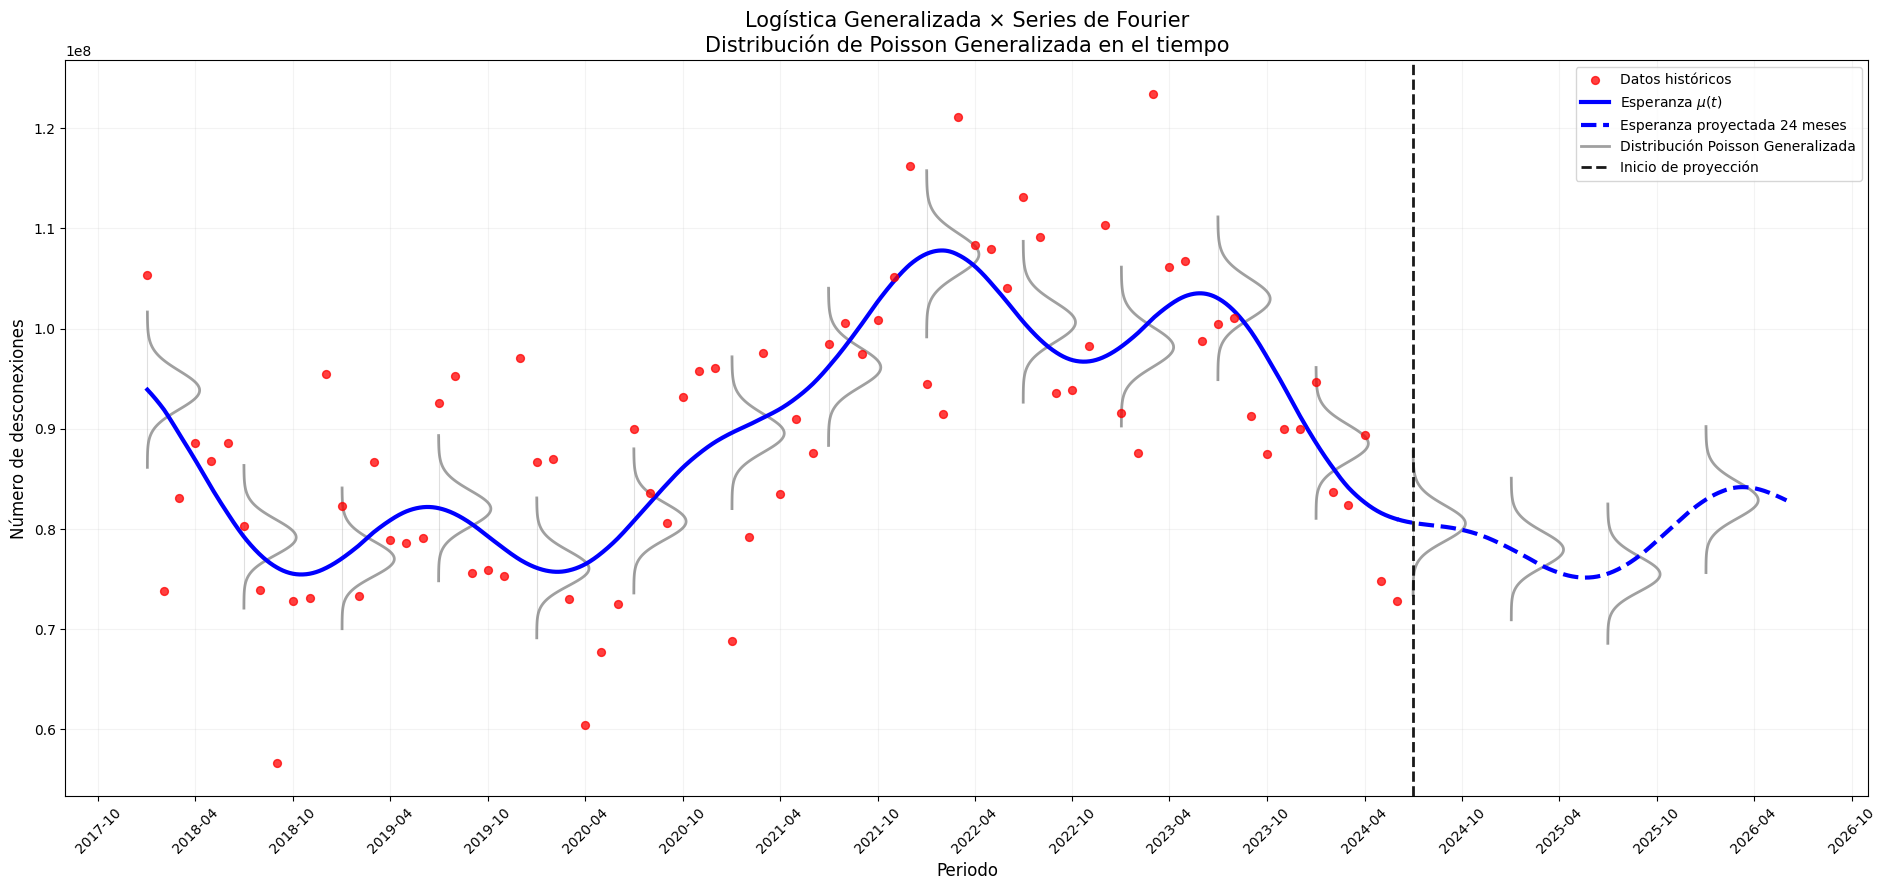



RESUMEN FINAL DEL MODELO
Mejor Loss = 17.43289096

Períodos iniciales:
    P1 = 12.0000 meses
    P2 = 24.0000 meses
    P3 = 96.0000 meses

Períodos aprendidos:
    P1 = 16.2247 meses
    P2 = 24.8389 meses
    P3 = 70.9983 meses

Amplitudes Fourier:
    R1 = 0.03746401
    R2 = 0.03518464
    R3 = 0.15546307

rho = 0.99895961

Dominio utilizado:
    P1, P2, P3 > 0, sin límite superior
    rho < 1, sin límite inferior artificial


In [83]:
# ============================================================
# MODELO:
# LOGÍSTICA GENERALIZADA × FOURIER
# DISTRIBUCIÓN DE POISSON GENERALIZADA
# OPTIMIZACIÓN CON TENSORFLOW
#
# Requiere que exista:
#
# df["PERIODO"]
# df["DESCONEXIONES"]
#
# ============================================================

import math
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.special import gammaln


# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

tf.keras.backend.set_floatx("float64")

DTYPE = tf.float64


# ------------------------------------------------------------
# ENTRENAMIENTO
# ------------------------------------------------------------

EPOCHS = 1000

LEARNING_RATE = 0.1

# Weight decay desacoplado del optimizador AdamW.
# Se aplica a TODAS las variables incluidas en `variables`, incluido raw_rho.
WEIGHT_DECAY = 1e-4

LAMBDA_RIDGE = 1e-4

PRINT_EVERY = 100

PATIENCE = 800


# ------------------------------------------------------------
# INICIALIZACIÓN DE LOS PERÍODOS FOURIER
#
# NO HAY P_MIN
# NO HAY P_MAX
#
# Los períodos solamente deben ser > 0.
#
# Unidades: meses
# ------------------------------------------------------------

P1_INIT = 12.0       # 1 año
P2_INIT = 12.0 * 2   # 2 años
P3_INIT = 12.0 * 8   # 8 años


# ------------------------------------------------------------
# POISSON GENERALIZADA
#
# rho es un parámetro ENTRENABLE.
#
# Puede explorar:
#
#     -infinito < rho < 1
#
# rho = 0  -> Poisson
# rho > 0  -> sobredispersión
# rho < 0  -> subdispersión
#
# El valor siguiente es SOLO la inicialización.
# ------------------------------------------------------------

rho_init = 0.99999


# ------------------------------------------------------------
# Penalización para impedir combinaciones fuera del soporte
#
# Si rho < 0 debe cumplirse:
#
# lambda_t + rho*y_t > 0
# ------------------------------------------------------------

SUPPORT_PENALTY = 1e3

EPS = tf.constant(
    1e-12,
    dtype=DTYPE
)


# ============================================================
# 2. PREPARAR DATOS
# ============================================================

data = df.copy()

data["PERIODO"] = pd.to_datetime(
    data["PERIODO"]
)

data = (
    data
    .sort_values("PERIODO")
    .dropna(
        subset=[
            "PERIODO",
            "DESCONEXIONES"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Comprobar que DESCONEXIONES sea un conteo no negativo
# ------------------------------------------------------------

if (data["DESCONEXIONES"] < 0).any():

    raise ValueError(
        "DESCONEXIONES debe contener valores >= 0 "
        "para utilizar la distribución de Poisson Generalizada."
    )


fecha_inicio = data[
    "PERIODO"
].iloc[0]


# ------------------------------------------------------------
# Tiempo en meses reales desde la primera observación
# ------------------------------------------------------------

t_np = (

    (
        data["PERIODO"].dt.year
        -
        fecha_inicio.year
    )
    * 12

    +

    (
        data["PERIODO"].dt.month
        -
        fecha_inicio.month
    )

).to_numpy(
    dtype=np.float64
)


y_np = data[
    "DESCONEXIONES"
].to_numpy(
    dtype=np.float64
)


# ------------------------------------------------------------
# Escalamiento de la variable
# ------------------------------------------------------------

Y_SCALE = np.median(
    y_np
)


if Y_SCALE <= 0:

    positivos = y_np[
        y_np > 0
    ]

    if len(positivos) > 0:

        Y_SCALE = np.mean(
            positivos
        )

    else:

        Y_SCALE = 1.0


if (
    not np.isfinite(Y_SCALE)
    or
    Y_SCALE <= 0
):

    Y_SCALE = 1.0


y_scaled_np = (
    y_np
    /
    Y_SCALE
)


t = tf.constant(
    t_np,
    dtype=DTYPE
)


y = tf.constant(
    y_np,
    dtype=DTYPE
)


T_HIST = float(
    t_np.max()
)


# ============================================================
# 3. FUNCIONES AUXILIARES
# ============================================================

def inv_softplus(x):
    """
    Inversa numéricamente estable de:

        y = softplus(x)

    para y > 0.
    """

    x = np.asarray(
        x,
        dtype=np.float64
    )

    if np.any(x <= 0):

        raise ValueError(
            "inv_softplus requiere valores > 0."
        )

    return (
        x
        +
        np.log(
            -np.expm1(-x)
        )
    )


# ============================================================
# 4. INICIALIZACIÓN LOGÍSTICA GENERALIZADA
# ============================================================

q05 = np.quantile(
    y_scaled_np,
    0.05
)

q95 = np.quantile(
    y_scaled_np,
    0.95
)


L_init = max(
    1e-3,
    q05 * 0.90
)


K_init = max(
    L_init + 0.05,
    q95 * 1.10
)


raw_L = tf.Variable(

    inv_softplus(
        L_init
    ),

    dtype=DTYPE,

    name="raw_L"
)


raw_Kdelta = tf.Variable(

    inv_softplus(
        K_init - L_init
    ),

    dtype=DTYPE,

    name="raw_Kdelta"
)


raw_A = tf.Variable(

    inv_softplus(
        1.0
    ),

    dtype=DTYPE,

    name="raw_A"
)


raw_r = tf.Variable(

    inv_softplus(
        0.025
    ),

    dtype=DTYPE,

    name="raw_r"
)


t0 = tf.Variable(

    T_HIST / 2.0,

    dtype=DTYPE,

    name="t0"
)


raw_nu = tf.Variable(

    inv_softplus(
        1.0
    ),

    dtype=DTYPE,

    name="raw_nu"
)


# ============================================================
# 5. PARÁMETROS FOURIER
# ============================================================

# ------------------------------------------------------------
# Coeficientes seno/coseno
# ------------------------------------------------------------

a1 = tf.Variable(
    0.0,
    dtype=DTYPE,
    name="a1"
)

b1 = tf.Variable(
    0.0,
    dtype=DTYPE,
    name="b1"
)


a2 = tf.Variable(
    0.0,
    dtype=DTYPE,
    name="a2"
)

b2 = tf.Variable(
    0.0,
    dtype=DTYPE,
    name="b2"
)


a3 = tf.Variable(
    0.0,
    dtype=DTYPE,
    name="a3"
)

b3 = tf.Variable(
    0.0,
    dtype=DTYPE,
    name="b3"
)


# ------------------------------------------------------------
# Comprobar inicializaciones
# ------------------------------------------------------------

for nombre, valor in [

    ("P1_INIT", P1_INIT),
    ("P2_INIT", P2_INIT),
    ("P3_INIT", P3_INIT)

]:

    if valor <= 0:

        raise ValueError(
            f"{nombre} debe ser > 0."
        )


# ------------------------------------------------------------
# PERIODOS FOURIER
#
# Ya NO utilizamos:
#
# P_MIN
# P_MAX
#
# Ahora:
#
# P_i = softplus(raw_P_i)
#
# Por tanto:
#
#            0 < P_i < infinito
#
# ------------------------------------------------------------

raw_P1 = tf.Variable(

    inv_softplus(
        P1_INIT
    ),

    dtype=DTYPE,

    name="raw_P1"
)


raw_P2 = tf.Variable(

    inv_softplus(
        P2_INIT
    ),

    dtype=DTYPE,

    name="raw_P2"
)


raw_P3 = tf.Variable(

    inv_softplus(
        P3_INIT
    ),

    dtype=DTYPE,

    name="raw_P3"
)


# ============================================================
# 6. PARÁMETRO rho
#    POISSON GENERALIZADA
# ============================================================

# ------------------------------------------------------------
# Queremos que:
#
#             rho < 1
#
# pero NO queremos imponer un rho mínimo.
#
# Utilizamos:
#
# rho = 1 - softplus(raw_rho)
#
# Por tanto:
#
#          -infinito < rho < 1
#
#
# Para inicializar:
#
# softplus(raw_rho) = 1-rho_init
#
# ------------------------------------------------------------

if rho_init >= 1.0:

    raise ValueError(
        "rho_init debe ser menor que 1."
    )


raw_rho = tf.Variable(

    inv_softplus(
        1.0 - rho_init
    ),

    dtype=DTYPE,

    name="raw_rho"
)


# ============================================================
# 7. PARÁMETROS TRANSFORMADOS
# ============================================================

def parametros_transformados():

    # --------------------------------------------------------
    # Logística Generalizada
    # --------------------------------------------------------

    L = tf.nn.softplus(
        raw_L
    )


    K = (
        L
        +
        tf.nn.softplus(
            raw_Kdelta
        )
    )


    A = (
        tf.nn.softplus(
            raw_A
        )
        +
        EPS
    )


    r = (
        tf.nn.softplus(
            raw_r
        )
        +
        EPS
    )


    nu = (
        tf.nn.softplus(
            raw_nu
        )
        +
        EPS
    )


    # --------------------------------------------------------
    # Fourier
    #
    # Sin P_MIN ni P_MAX
    #
    # 0 < Pi < infinito
    # --------------------------------------------------------

    P1 = (
        tf.nn.softplus(
            raw_P1
        )
        +
        EPS
    )


    P2 = (
        tf.nn.softplus(
            raw_P2
        )
        +
        EPS
    )


    P3 = (
        tf.nn.softplus(
            raw_P3
        )
        +
        EPS
    )


    # --------------------------------------------------------
    # rho
    #
    # Libre dentro del dominio:
    #
    # rho < 1
    # --------------------------------------------------------

    rho = (
        1.0
        -
        tf.nn.softplus(
            raw_rho
        )
    )


    return (

        L,
        K,
        A,
        r,
        t0,
        nu,

        P1,
        P2,
        P3,

        rho
    )


# ============================================================
# 8. MODELO TEMPORAL
# ============================================================

def modelo_mu(t_eval):

    (
        L,
        K,
        A,
        r,
        t0_,
        nu,
        P1,
        P2,
        P3,
        rho

    ) = parametros_transformados()


    # --------------------------------------------------------
    # TENDENCIA LOGÍSTICA GENERALIZADA
    # --------------------------------------------------------

    expo = (

        -r

        *

        (
            t_eval
            -
            t0_
        )
    )


    expo = tf.clip_by_value(

        expo,

        -60.0,

        60.0
    )


    g = (

        L

        +

        (K - L)

        /

        tf.pow(

            1.0

            +

            A
            *
            tf.exp(
                expo
            ),

            1.0 / nu
        )
    )


    # --------------------------------------------------------
    # FOURIER
    # --------------------------------------------------------

    two_pi = tf.constant(

        2.0 * np.pi,

        dtype=DTYPE
    )


    s = (

        a1
        *
        tf.cos(
            two_pi
            *
            t_eval
            /
            P1
        )

        +

        b1
        *
        tf.sin(
            two_pi
            *
            t_eval
            /
            P1
        )


        +

        a2
        *
        tf.cos(
            two_pi
            *
            t_eval
            /
            P2
        )

        +

        b2
        *
        tf.sin(
            two_pi
            *
            t_eval
            /
            P2
        )


        +

        a3
        *
        tf.cos(
            two_pi
            *
            t_eval
            /
            P3
        )

        +

        b3
        *
        tf.sin(
            two_pi
            *
            t_eval
            /
            P3
        )
    )


    # --------------------------------------------------------
    # Evitar explosiones numéricas
    # --------------------------------------------------------

    s = tf.clip_by_value(

        s,

        -1.5,

        1.5
    )


    # --------------------------------------------------------
    # MODELO MULTIPLICATIVO
    # --------------------------------------------------------

    mu_scaled = (

        g

        *

        tf.exp(
            s
        )
    )


    mu = (

        mu_scaled

        *

        Y_SCALE
    )


    mu = tf.maximum(

        mu,

        EPS
    )


    return mu


# ============================================================
# 9. NLL POISSON GENERALIZADA
# ============================================================

def nll_poisson_generalizada(
    y_obs,
    mu
):

    *_, rho = parametros_transformados()


    # --------------------------------------------------------
    # Parametrización
    #
    # E[Y] = mu
    #
    # lambda = mu(1-rho)
    #
    # Como rho < 1:
    #
    # lambda > 0
    # --------------------------------------------------------

    lambda_t = (

        mu

        *

        (1.0 - rho)
    )


    # --------------------------------------------------------
    # Segundo término de la Poisson Generalizada
    #
    # Debe cumplirse:
    #
    # lambda + rho*y > 0
    # --------------------------------------------------------

    term = (

        lambda_t

        +

        rho
        *
        y_obs
    )


    # --------------------------------------------------------
    # Valor seguro SOLO para evaluar el log.
    #
    # Las combinaciones inválidas reciben además una
    # penalización explícita.
    # --------------------------------------------------------

    term_safe = tf.maximum(

        term,

        EPS
    )


    lambda_safe = tf.maximum(

        lambda_t,

        EPS
    )


    # --------------------------------------------------------
    # Log-verosimilitud
    # --------------------------------------------------------

    log_p = (

        tf.math.log(
            lambda_safe
        )

        +

        (y_obs - 1.0)

        *

        tf.math.log(
            term_safe
        )

        -

        term_safe

        -

        tf.math.lgamma(
            y_obs + 1.0
        )
    )


    nll = -tf.reduce_mean(
        log_p
    )


    # --------------------------------------------------------
    # RESTRICCIÓN DEL SOPORTE
    #
    # Si rho < 0 puede ocurrir:
    #
    # lambda + rho*y <= 0
    #
    # Eso corresponde a una combinación inválida.
    #
    # No queremos simplemente hacer:
    #
    # term = maximum(term, EPS)
    #
    # porque eso escondería el problema.
    #
    # Por eso agregamos una penalización.
    # --------------------------------------------------------

    invalid_support = tf.nn.relu(

        EPS
        -
        term
    )


    support_scale = tf.stop_gradient(

        tf.maximum(

            tf.reduce_mean(
                mu
            ),

            tf.constant(
                1.0,
                dtype=DTYPE
            )
        )
    )


    support_penalty = (

        SUPPORT_PENALTY

        *

        tf.reduce_mean(

            tf.square(

                invalid_support

                /

                support_scale
            )
        )
    )


    return (
        nll,
        support_penalty
    )


# ============================================================
# 10. REGULARIZACIÓN RIDGE
# ============================================================

def ridge():

    return (

        LAMBDA_RIDGE

        *

        (

            a1**2
            +
            b1**2

            +

            a2**2
            +
            b2**2

            +

            a3**2
            +
            b3**2

            +

            0.01
            *
            raw_r**2

            +

            0.01
            *
            raw_nu**2
        )
    )


# ============================================================
# 11. FUNCIÓN OBJETIVO
# ============================================================

def loss_function():

    mu = modelo_mu(
        t
    )


    nll, support_penalty = (
        nll_poisson_generalizada(
            y,
            mu
        )
    )


    reg = ridge()


    loss = (

        nll

        +

        support_penalty

        +

        reg
    )


    return (
        loss,
        nll,
        support_penalty,
        reg
    )


# ============================================================
# 12. VARIABLES ENTRENABLES
# ============================================================

variables = [

    raw_L,
    raw_Kdelta,
    raw_A,
    raw_r,
    t0,
    raw_nu,

    a1,
    b1,
    raw_P1,

    a2,
    b2,
    raw_P2,

    a3,
    b3,
    raw_P3,

    raw_rho
]


# ============================================================
# 13. OPTIMIZADOR
# ============================================================

optimizer = tf.keras.optimizers.AdamW(

    learning_rate=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY,

    clipnorm=5.0
)


# ============================================================
# 14. MOSTRAR INICIALIZACIÓN
# ============================================================

print("\n============================================================")
print("INICIALIZACIÓN")
print("============================================================")

print(
    f"P1 inicial  = {P1_INIT:.6f} meses"
)

print(
    f"P2 inicial  = {P2_INIT:.6f} meses"
)

print(
    f"P3 inicial  = {P3_INIT:.6f} meses"
)

print(
    f"rho inicial = {rho_init:.6f}"
)

print("============================================================\n")


# ============================================================
# 15. ENTRENAMIENTO
# ============================================================

best_loss = np.inf

best_values = None

contador = 0


for epoch in range(EPOCHS):

    with tf.GradientTape() as tape:

        (
            loss,
            nll,
            support_penalty,
            reg

        ) = loss_function()


    grads = tape.gradient(

        loss,

        variables
    )


    grads_vars = [

        (g, v)

        for g, v in zip(
            grads,
            variables
        )

        if g is not None
    ]


    optimizer.apply_gradients(
        grads_vars
    )


    current_loss = float(
        loss.numpy()
    )


    # --------------------------------------------------------
    # Guardar mejor solución
    # --------------------------------------------------------

    if (

        np.isfinite(
            current_loss
        )

        and

        current_loss
        <
        best_loss - 1e-9
    ):

        best_loss = current_loss


        best_values = [

            v.numpy().copy()

            for v in variables
        ]


        contador = 0


    else:

        contador += 1


    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    if epoch % PRINT_EVERY == 0:

        (
            L_temp,
            K_temp,
            A_temp,
            r_temp,
            t0_temp,
            nu_temp,
            P1_temp,
            P2_temp,
            P3_temp,
            rho_temp

        ) = parametros_transformados()


        print(

            f"Epoch {epoch:5d} | "

            f"Loss = {float(loss.numpy()):.6f} | "

            f"NLL = {float(nll.numpy()):.6f} | "

            f"Support = "
            f"{float(support_penalty.numpy()):.6f} | "

            f"Ridge = {float(reg.numpy()):.6f} | "

            f"rho = {float(rho_temp.numpy()):.6f} | "

            f"P = ["

            f"{float(P1_temp.numpy()):.3f}, "

            f"{float(P2_temp.numpy()):.3f}, "

            f"{float(P3_temp.numpy()):.3f}"

            f"]"
        )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if contador >= PATIENCE:

        print(
            f"\nEarly stopping en epoch {epoch}"
        )

        break


# ============================================================
# 16. RESTAURAR MEJOR SOLUCIÓN
# ============================================================

if best_values is not None:

    for variable, value in zip(

        variables,

        best_values
    ):

        variable.assign(
            value
        )


# ============================================================
# 17. PARÁMETROS ESTIMADOS
# ============================================================

(
    L_,
    K_,
    A_,
    r_,
    t0_,
    nu_,
    P1_,
    P2_,
    P3_,
    rho_

) = parametros_transformados()


# ============================================================
# 18. INTERPRETAR PERÍODOS
# ============================================================

def interpretar_periodo(P):

    if np.isclose(
        P,
        1.0,
        rtol=0.05
    ):

        return "mensual"


    if np.isclose(
        P,
        2.0,
        rtol=0.05
    ):

        return "bimestral"


    if np.isclose(
        P,
        3.0,
        rtol=0.05
    ):

        return "trimestral"


    if np.isclose(
        P,
        4.0,
        rtol=0.05
    ):

        return "cuatrimestral"


    if np.isclose(
        P,
        6.0,
        rtol=0.05
    ):

        return "semestral"


    if np.isclose(
        P,
        12.0,
        rtol=0.05
    ):

        return "anual"


    if P >= 12.0:

        return (
            f"cada {P/12.0:.2f} años"
        )


    return (
        f"cada {P:.2f} meses"
    )


# ============================================================
# 19. EXTRAER VALORES
# ============================================================

P1_val = float(
    P1_.numpy()
)

P2_val = float(
    P2_.numpy()
)

P3_val = float(
    P3_.numpy()
)


a1_val = float(
    a1.numpy()
)

b1_val = float(
    b1.numpy()
)


a2_val = float(
    a2.numpy()
)

b2_val = float(
    b2.numpy()
)


a3_val = float(
    a3.numpy()
)

b3_val = float(
    b3.numpy()
)


rho_value = float(
    rho_.numpy()
)


# ============================================================
# 20. AMPLITUDES Y FASES FOURIER
# ============================================================

R1 = np.sqrt(
    a1_val**2
    +
    b1_val**2
)

R2 = np.sqrt(
    a2_val**2
    +
    b2_val**2
)

R3 = np.sqrt(
    a3_val**2
    +
    b3_val**2
)


phi1 = np.arctan2(
    b1_val,
    a1_val
)

phi2 = np.arctan2(
    b2_val,
    a2_val
)

phi3 = np.arctan2(
    b3_val,
    a3_val
)


# ============================================================
# 21. PRINT PARÁMETROS ESTIMADOS
# ============================================================

print("\n")
print("============================================================")
print("PARÁMETROS ESTIMADOS")
print("============================================================")

print(
    f"L   = {float(L_.numpy() * Y_SCALE):.8f}"
)

print(
    f"K   = {float(K_.numpy() * Y_SCALE):.8f}"
)

print(
    f"A   = {float(A_.numpy()):.8f}"
)

print(
    f"r   = {float(r_.numpy()):.8f}"
)

print(
    f"t0  = {float(t0_.numpy()):.8f}"
)

print(
    f"nu  = {float(nu_.numpy()):.8f}"
)

print(
    f"rho = {rho_value:.8f}"
)


if rho_value > 0:

    print(
        "Dispersión: SOBREDISPERSIÓN"
    )

elif rho_value < 0:

    print(
        "Dispersión: SUBDISPERSIÓN"
    )

else:

    print(
        "Dispersión: POISSON"
    )


print("============================================================")


# ============================================================
# 22. PRINT PERÍODOS FOURIER
# ============================================================

print("\n")
print("============================================================")
print("PERÍODOS FOURIER APRENDIDOS")
print("============================================================")


print(

    f"P1 | "

    f"inicial = {P1_INIT:9.4f} meses | "

    f"aprendido = {P1_val:9.4f} meses | "

    f"{interpretar_periodo(P1_val)} | "

    f"ciclos/año = {12.0/P1_val:9.4f} | "

    f"amplitud = {R1:10.6f} | "

    f"fase = {phi1:9.5f} rad"
)


print(

    f"P2 | "

    f"inicial = {P2_INIT:9.4f} meses | "

    f"aprendido = {P2_val:9.4f} meses | "

    f"{interpretar_periodo(P2_val)} | "

    f"ciclos/año = {12.0/P2_val:9.4f} | "

    f"amplitud = {R2:10.6f} | "

    f"fase = {phi2:9.5f} rad"
)


print(

    f"P3 | "

    f"inicial = {P3_INIT:9.4f} meses | "

    f"aprendido = {P3_val:9.4f} meses | "

    f"{interpretar_periodo(P3_val)} | "

    f"ciclos/año = {12.0/P3_val:9.4f} | "

    f"amplitud = {R3:10.6f} | "

    f"fase = {phi3:9.5f} rad"
)


print("============================================================")


# ============================================================
# 23. COEFICIENTES FOURIER
# ============================================================

print("\n")
print("============================================================")
print("COEFICIENTES FOURIER")
print("============================================================")

print(
    f"a1 = {a1_val:.8f}"
)

print(
    f"b1 = {b1_val:.8f}"
)

print()

print(
    f"a2 = {a2_val:.8f}"
)

print(
    f"b2 = {b2_val:.8f}"
)

print()

print(
    f"a3 = {a3_val:.8f}"
)

print(
    f"b3 = {b3_val:.8f}"
)

print("============================================================")


# ============================================================
# 24. PROYECCIÓN 24 MESES
# ============================================================

ultima_fecha = data[
    "PERIODO"
].max()


fechas_forecast = pd.date_range(

    ultima_fecha
    +
    pd.offsets.MonthBegin(1),

    periods=24,

    freq="MS"
)


t_forecast = np.arange(

    T_HIST + 1,

    T_HIST + 25,

    dtype=np.float64
)


mu_forecast = modelo_mu(

    tf.constant(

        t_forecast,

        dtype=DTYPE
    )

).numpy()


df_forecast = pd.DataFrame({

    "PERIODO":
        fechas_forecast,

    "DESCONEXIONES_PREDICHAS":
        mu_forecast
})


print("\n")
print("============================================================")
print("PRONÓSTICO 24 MESES")
print("============================================================")

print(

    df_forecast.to_string(
        index=False
    )
)


# ============================================================
# 25. INTERPOLACIÓN CONTINUA
# ============================================================

t_dense = np.linspace(

    0,

    T_HIST + 24,

    2000
)


mu_dense = modelo_mu(

    tf.constant(

        t_dense,

        dtype=DTYPE
    )

).numpy()


# ============================================================
# 26. CONVERTIR t CONTINUO A FECHA
# ============================================================

fechas_todas_mensuales = pd.date_range(

    fecha_inicio,

    periods=int(T_HIST) + 25,

    freq="MS"
)


t_mensual_completo = np.arange(

    len(
        fechas_todas_mensuales
    )
)


fechas_num_mensual = mdates.date2num(

    fechas_todas_mensuales
)


fecha_dense_num = np.interp(

    t_dense,

    t_mensual_completo,

    fechas_num_mensual
)


fecha_dense = mdates.num2date(
    fecha_dense_num
)


# ============================================================
# 27. MEDIA Y DESVIACIÓN ESTÁNDAR
#     POISSON GENERALIZADA
# ============================================================

# ------------------------------------------------------------
# Con:
#
# lambda = mu(1-rho)
#
# tenemos:
#
# E[Y] = mu
#
# Var[Y] = mu/(1-rho)^2
#
# sigma = sqrt(mu)/(1-rho)
#
# Como rho < 1:
#
# 1-rho > 0
# ------------------------------------------------------------

sigma_dense = (

    np.sqrt(
        mu_dense
    )

    /

    (
        1.0
        -
        rho_value
    )
)


# ============================================================
# 28. FUNCIÓN PMF POISSON GENERALIZADA
# ============================================================

def gp_profile(
    mu,
    rho,
    n=80
):

    sigma = (

        np.sqrt(
            mu
        )

        /

        (1.0 - rho)
    )


    y_min = max(

        0,

        mu
        -
        4.0 * sigma
    )


    y_max = (

        mu

        +

        4.0 * sigma
    )


    yy = np.unique(

        np.round(

            np.linspace(

                y_min,

                y_max,

                n
            )

        ).astype(
            np.int64
        )
    )


    lambda_ = (

        mu

        *

        (1.0 - rho)
    )


    term = (

        lambda_

        +

        rho
        *
        yy
    )


    # --------------------------------------------------------
    # Para rho < 0 el soporte puede ser finito.
    # Conservamos solamente puntos válidos.
    # --------------------------------------------------------

    valid = (
        term > 0
    )


    yy = yy[
        valid
    ]

    term = term[
        valid
    ]


    if len(yy) == 0:

        return (
            np.array([]),
            np.array([])
        )


    log_p = (

        np.log(
            lambda_
        )

        +

        (yy - 1)

        *

        np.log(
            term
        )

        -

        term

        -

        gammaln(
            yy + 1
        )
    )


    log_p = (

        log_p

        -

        np.max(
            log_p
        )
    )


    p = np.exp(
        log_p
    )


    if np.max(p) > 0:

        p = (

            p

            /

            np.max(p)
        )


    return (
        yy,
        p
    )


# ============================================================
# 29. PREDICCIÓN EN TODOS LOS MESES
# ============================================================

t_all = np.arange(

    0,

    T_HIST + 25,

    dtype=np.float64
)


mu_all = modelo_mu(

    tf.constant(

        t_all,

        dtype=DTYPE
    )

).numpy()


fechas_all = pd.date_range(

    fecha_inicio,

    periods=len(
        t_all
    ),

    freq="MS"
)

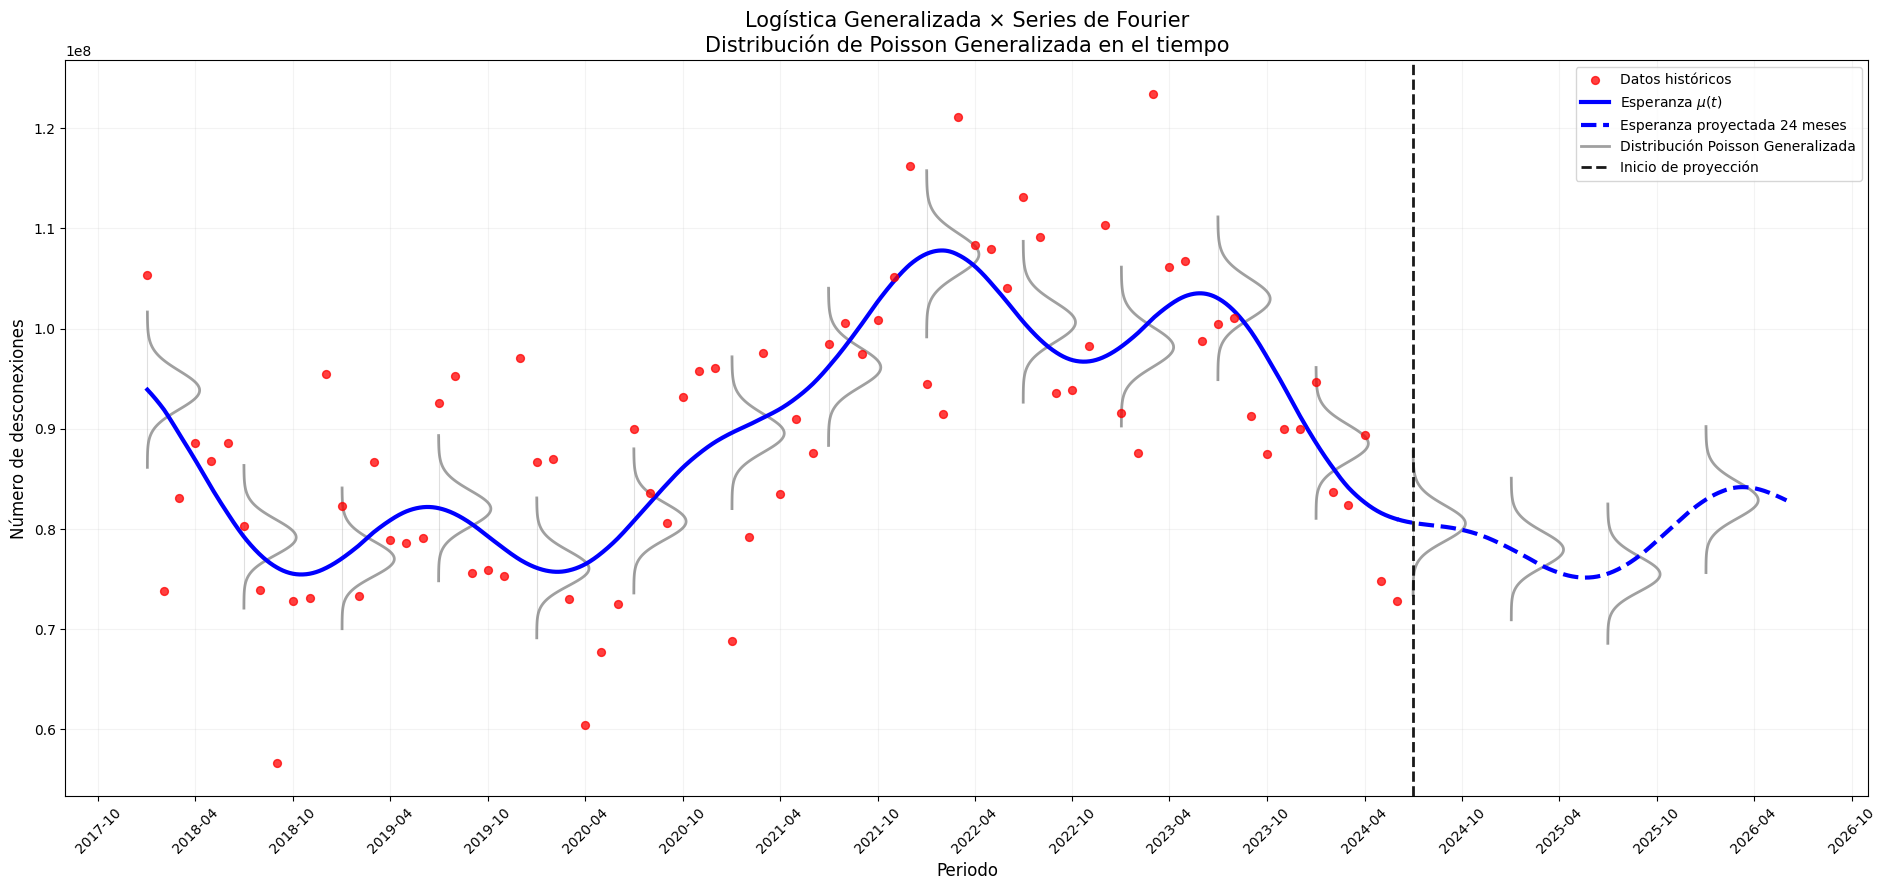



RESUMEN FINAL DEL MODELO
Mejor Loss = 17.55458807

Períodos iniciales:
    P1 = 12.0000 meses
    P2 = 24.0000 meses
    P3 = 96.0000 meses

Períodos aprendidos:
    P1 = 16.2247 meses
    P2 = 24.8389 meses
    P3 = 70.9983 meses

Amplitudes Fourier:
    R1 = 0.03746401
    R2 = 0.03518464
    R3 = 0.15546307

rho = 0.99895961

Dominio utilizado:
    P1, P2, P3 > 0, sin límite superior
    rho < 1, sin límite inferior artificial


In [115]:


# ============================================================
# 30. GRÁFICO
#     PMF POISSON GENERALIZADA EN EL TIEMPO
# ============================================================

# ============================================================
# CONFIGURACIÓN VISUAL
# ============================================================

EPS_PLOT = 1e-9

PMF_CADA_N_PERIODOS = 6
PMF_N_SIGMAS = 4.0
PMF_MAX_PUNTOS = 120

PMF_ANCHO_MAX_DIAS = 70.0
PMF_ANCHO_REL_MIN = 0.65
PMF_ANCHO_REL_MAX = 1.40

PMF_ALPHA_HIST = 0.75
PMF_ALPHA_FORECAST = 0.75
PMF_LINEWIDTH = 2.0

PMF_CENTER_ALPHA = 0.25
PMF_CENTER_LINEWIDTH = 0.8


# ============================================================
# 30.1 LOG-PMF POISSON GENERALIZADA
# ============================================================

def gp_log_pmf_plot(k, mu, rho):

    k = np.asarray(k, dtype=float)

    mu = float(max(mu, EPS_PLOT))

    rho = float(np.clip(rho, -0.95, 0.995))

    lam = max(mu * (1.0 - rho), EPS_PLOT)

    a = np.maximum(lam + rho * k, EPS_PLOT)

    lgamma_k = np.array([
        math.lgamma(float(v) + 1.0)
        for v in k
    ])

    logp = (
        np.log(lam)
        + (k - 1.0) * np.log(a)
        - a
        - lgamma_k
    )

    logp = np.where(
        k <= 0,
        -lam,
        logp
    )

    return np.where(
        np.isfinite(logp),
        logp,
        -745.0
    )


# ============================================================
# 30.2 SOPORTE DE LA DISTRIBUCIÓN
# ============================================================

def gp_pmf_soporte_plot(
    mu,
    rho,
    n_sigmas=PMF_N_SIGMAS,
    max_points=PMF_MAX_PUNTOS
):

    mu = float(max(mu, EPS_PLOT))
    rho = float(np.clip(rho, -0.95, 0.995))

    sigma = (
        np.sqrt(mu)
        /
        max(1.0 - rho, EPS_PLOT)
    )

    k_min = max(
        0.0,
        mu - n_sigmas * sigma
    )

    k_max = (
        mu
        + n_sigmas * sigma
    )

    k = np.unique(
        np.round(
            np.linspace(
                k_min,
                k_max,
                max_points
            )
        ).astype(int)
    )

    logp = gp_log_pmf_plot(
        k,
        mu,
        rho
    )

    logp -= np.max(logp)

    p = np.exp(logp)

    p = np.where(
        np.isfinite(p),
        p,
        0.0
    )

    if np.max(p) > 0:
        p /= np.max(p)

    return (
        k.astype(float),
        p.astype(float),
        sigma
    )


# ============================================================
# 30.3 FECHAS
# ============================================================

fechas_all = pd.date_range(
    fecha_inicio,
    periods=len(mu_all),
    freq="MS"
)

fechas_all_num = mdates.date2num(
    fechas_all
)

corte = data["PERIODO"].max()


# ============================================================
# 30.4 ÍNDICES DONDE MOSTRAREMOS DISTRIBUCIONES
# ============================================================

indices_pmf = np.arange(
    0,
    len(mu_all),
    PMF_CADA_N_PERIODOS
)


# ============================================================
# 30.5 SIGMA DE REFERENCIA
# ============================================================

sigmas = np.array([
    np.sqrt(mu_all[i])
    /
    max(1.0 - rho_value, EPS_PLOT)
    for i in indices_pmf
])

sigma_ref = max(
    np.median(sigmas),
    EPS_PLOT
)


# ============================================================
# 30.6 FIGURA
# ============================================================

fig, ax = plt.subplots(
    figsize=(19, 9)
)


# ============================================================
# DATOS REALES: ROJO
# ============================================================

ax.scatter(
    data["PERIODO"],
    y_np,
    s=32,
    color="red",
    alpha=0.75,
    label="Datos históricos",
    zorder=10
)


# ============================================================
# ESPERANZA / MEDIA: AZUL
# ============================================================

mask_hist = (
    t_dense <= T_HIST
)

ax.plot(
    fecha_dense_num[mask_hist],
    mu_dense[mask_hist],
    color="blue",
    linewidth=3.0,
    label=r"Esperanza $\mu(t)$",
    zorder=9
)


# ============================================================
# PROYECCIÓN DE LA ESPERANZA: AZUL PUNTEADA
# ============================================================

mask_forecast = (
    t_dense >= T_HIST
)

ax.plot(
    fecha_dense_num[mask_forecast],
    mu_dense[mask_forecast],
    color="blue",
    linewidth=3.0,
    linestyle="--",
    label="Esperanza proyectada 24 meses",
    zorder=9
)


# ============================================================
# 30.7 DISTRIBUCIONES GP: TODAS GRISES
# ============================================================

label_dist_usado = False

for i in indices_pmf:

    mu_i = float(
        mu_all[i]
    )

    fecha_i = fechas_all[i]

    x0 = mdates.date2num(
        fecha_i
    )

    (
        k_vals,
        p_vals,
        sigma_i

    ) = gp_pmf_soporte_plot(
        mu=mu_i,
        rho=rho_value
    )

    ancho_rel = np.clip(
        np.sqrt(
            sigma_ref
            /
            max(
                sigma_i,
                EPS_PLOT
            )
        ),
        PMF_ANCHO_REL_MIN,
        PMF_ANCHO_REL_MAX
    )

    dx = (
        p_vals
        *
        PMF_ANCHO_MAX_DIAS
        *
        ancho_rel
    )

    x_dist = (
        x0
        +
        dx
    )

    if not label_dist_usado:

        texto_label = (
            "Distribución Poisson Generalizada"
        )

        label_dist_usado = True

    else:

        texto_label = "_nolegend_"

    # Curva de la distribución
    ax.plot(
        x_dist,
        k_vals,
        color="gray",
        linewidth=PMF_LINEWIDTH,
        alpha=PMF_ALPHA_HIST,
        label=texto_label,
        zorder=6
    )

    # Línea vertical de origen
    ax.plot(
        [x0, x0],
        [
            np.min(k_vals),
            np.max(k_vals)
        ],
        color="gray",
        linewidth=PMF_CENTER_LINEWIDTH,
        alpha=PMF_CENTER_ALPHA,
        zorder=3
    )


# ============================================================
# 30.8 INICIO DE LA PROYECCIÓN: NEGRO
# ============================================================

fecha_inicio_forecast = (
    corte
    +
    pd.offsets.MonthBegin(1)
)

ax.axvline(
    fecha_inicio_forecast,
    color="black",
    linestyle="--",
    linewidth=2,
    alpha=0.9,
    label="Inicio de proyección",
    zorder=12
)


# ============================================================
# 30.9 FORMATO
# ============================================================

ax.set_title(
    "Logística Generalizada × Series de Fourier\n"
    "Distribución de Poisson Generalizada en el tiempo",
    fontsize=15
)

ax.set_xlabel(
    "Periodo",
    fontsize=12
)

ax.set_ylabel(
    "Número de desconexiones",
    fontsize=12
)

ax.grid(
    True,
    alpha=0.15
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(
        interval=6
    )
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%Y-%m"
    )
)

plt.xticks(
    rotation=45
)

ax.legend(
    fontsize=10,
    loc="best"
)

plt.tight_layout()
plt.show()


# ============================================================
# 31. RESUMEN FINAL
# ============================================================

print("\n")
print("============================================================")
print("RESUMEN FINAL DEL MODELO")
print("============================================================")

print(
    f"Mejor Loss = {best_loss:.8f}"
)

print()

print(
    "Períodos iniciales:"
)

print(
    f"    P1 = {P1_INIT:.4f} meses"
)

print(
    f"    P2 = {P2_INIT:.4f} meses"
)

print(
    f"    P3 = {P3_INIT:.4f} meses"
)


print()

print(
    "Períodos aprendidos:"
)

print(
    f"    P1 = {P1_val:.4f} meses"
)

print(
    f"    P2 = {P2_val:.4f} meses"
)

print(
    f"    P3 = {P3_val:.4f} meses"
)


print()

print(
    "Amplitudes Fourier:"
)

print(
    f"    R1 = {R1:.8f}"
)

print(
    f"    R2 = {R2:.8f}"
)

print(
    f"    R3 = {R3:.8f}"
)


print()

print(
    f"rho = {rho_value:.8f}"
)


print()

print(
    "Dominio utilizado:"
)

print(
    "    P1, P2, P3 > 0, sin límite superior"
)

print(
    "    rho < 1, sin límite inferior artificial"
)

print("============================================================")

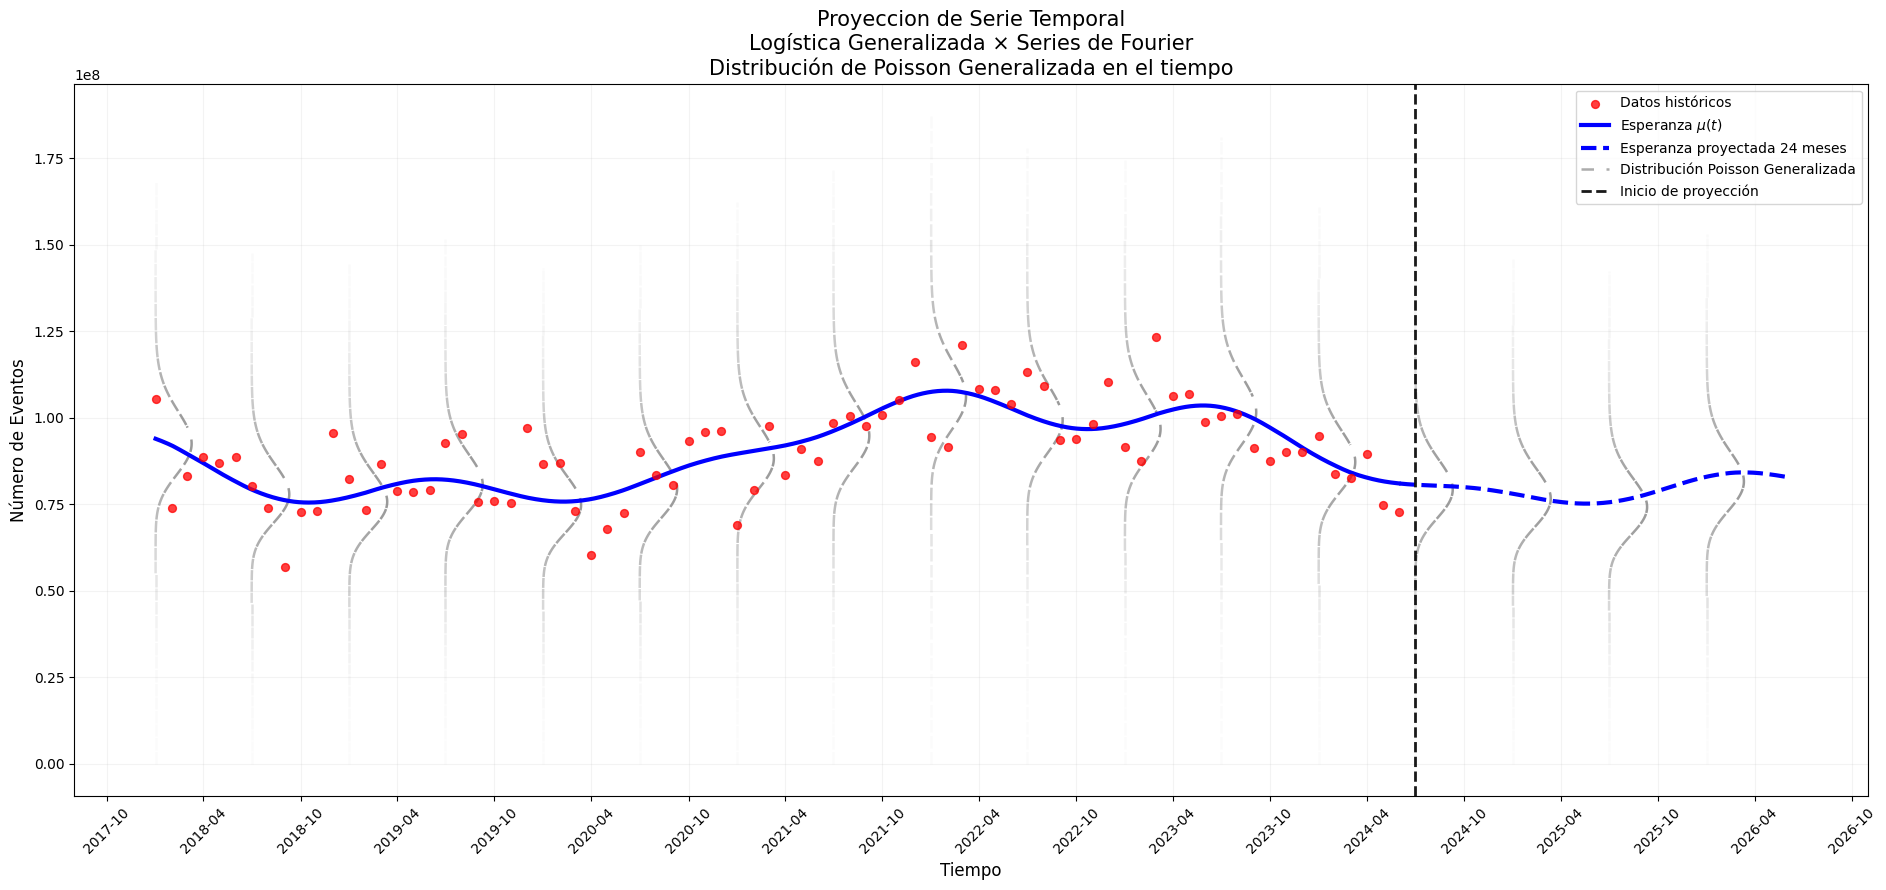

In [116]:
# ============================================================
# PLOT
# PROYECCION DE SERIE TEMPORAL
# ============================================================

EPS_PLOT = 1e-12

PMF_CADA_N_PERIODOS = 6
PMF_TAIL_REL = 1e-7
PMF_MAX_PUNTOS = 500

PMF_ANCHO_MAX_DIAS = 70.0
PMF_ANCHO_REL_MIN = 0.65
PMF_ANCHO_REL_MAX = 1.40

PMF_LINEWIDTH = 1.8

# Línea:
#
# - - - - - - - -
#
PMF_LINESTYLE = (0, (5, 5))

PMF_ALPHA_MAX = 0.80
PMF_ALPHA_MIN = 0.03
PMF_ALPHA_BANDS = 24
PMF_ALPHA_DECAY_SIGMAS = 2.5


# ============================================================
# LOG-PMF POISSON GENERALIZADA
# ============================================================

def gp_log_pmf_plot(k, mu, rho):

    k = np.asarray(
        k,
        dtype=np.float64
    )

    mu = float(
        max(mu, EPS_PLOT)
    )

    rho = float(rho)

    if rho >= 1.0:
        raise ValueError(
            "rho debe ser menor que 1."
        )

    lam = (
        mu
        *
        (1.0 - rho)
    )

    lam = max(
        lam,
        EPS_PLOT
    )

    term = (
        lam
        +
        rho * k
    )

    logp = np.full_like(
        k,
        -np.inf,
        dtype=np.float64
    )

    # y = 0
    mask_zero = (
        k == 0
    )

    logp[
        mask_zero
    ] = -lam

    # y > 0
    mask_positive = (
        (k > 0)
        &
        (term > 0)
    )

    if np.any(mask_positive):

        kk = k[
            mask_positive
        ]

        aa = term[
            mask_positive
        ]

        lgamma_k = np.array([
            math.lgamma(
                float(v) + 1.0
            )
            for v in kk
        ])

        logp[
            mask_positive
        ] = (
            np.log(lam)
            +
            (kk - 1.0)
            *
            np.log(aa)
            -
            aa
            -
            lgamma_k
        )

    return logp


# ============================================================
# SOPORTE COMPLETO / ADAPTATIVO
# ============================================================

def gp_pmf_soporte_plot(
    mu,
    rho,
    tail_rel=PMF_TAIL_REL,
    max_points=PMF_MAX_PUNTOS
):

    mu = float(
        max(mu, EPS_PLOT)
    )

    rho = float(rho)

    if rho >= 1.0:
        raise ValueError(
            "rho debe ser menor que 1."
        )

    sigma = (
        np.sqrt(mu)
        /
        max(
            1.0 - rho,
            EPS_PLOT
        )
    )

    lam = (
        mu
        *
        (1.0 - rho)
    )


    # ========================================================
    # rho < 0
    # soporte finito
    # ========================================================

    if rho < 0.0:

        k_max_exact = (
            lam
            /
            (-rho)
        )

        k_max = int(
            np.floor(
                k_max_exact
                -
                1e-10
            )
        )

        k_max = max(
            0,
            k_max
        )


    # ========================================================
    # rho >= 0
    # soporte 0,1,2,...,+infinito
    # ========================================================

    else:

        k_max = int(
            np.ceil(
                mu
                +
                8.0 * sigma
            )
        )

        k_max = max(
            k_max,
            20
        )

        k_peak_probe = np.unique(
            np.round(
                np.linspace(
                    0,
                    max(k_max, 20),
                    300
                )
            ).astype(
                np.int64
            )
        )

        logp_peak_probe = gp_log_pmf_plot(
            k_peak_probe,
            mu,
            rho
        )

        finite_peak = np.isfinite(
            logp_peak_probe
        )

        if np.any(finite_peak):

            logp_max = np.max(
                logp_peak_probe[
                    finite_peak
                ]
            )

        else:

            logp_max = 0.0

        log_tail_limite = (
            logp_max
            +
            np.log(
                tail_rel
            )
        )

        # Expandir la cola hasta que sea despreciable
        for _ in range(30):

            inicio_cola = max(
                0,
                int(
                    0.97 * k_max
                )
            )

            probe_tail = np.unique(
                np.round(
                    np.linspace(
                        inicio_cola,
                        k_max,
                        30
                    )
                ).astype(
                    np.int64
                )
            )

            logp_tail = gp_log_pmf_plot(
                probe_tail,
                mu,
                rho
            )

            finite_tail = np.isfinite(
                logp_tail
            )

            if (
                np.any(finite_tail)
                and
                np.max(
                    logp_tail[
                        finite_tail
                    ]
                )
                <=
                log_tail_limite
            ):
                break

            k_max = int(
                max(
                    k_max + 1,
                    np.ceil(
                        k_max * 1.5
                    )
                )
            )


    # ========================================================
    # MALLA PARA GRAFICAR
    # ========================================================

    numero_soporte = (
        k_max + 1
    )

    if numero_soporte <= max_points:

        k = np.arange(
            0,
            k_max + 1,
            dtype=np.int64
        )

    else:

        k = np.unique(
            np.concatenate([
                np.round(
                    np.linspace(
                        0,
                        k_max,
                        max_points
                    )
                ).astype(
                    np.int64
                ),

                np.array(
                    [
                        int(
                            np.clip(
                                round(mu),
                                0,
                                k_max
                            )
                        )
                    ],
                    dtype=np.int64
                )
            ])
        )

    logp = gp_log_pmf_plot(
        k,
        mu,
        rho
    )

    finite = np.isfinite(
        logp
    )

    k = k[
        finite
    ]

    logp = logp[
        finite
    ]

    if len(k) == 0:

        return (
            np.array([]),
            np.array([]),
            sigma
        )

    # Normalización solamente visual
    logp = (
        logp
        -
        np.max(logp)
    )

    p = np.exp(
        logp
    )

    p = np.where(
        np.isfinite(p),
        p,
        0.0
    )

    if np.max(p) > 0:

        p = (
            p
            /
            np.max(p)
        )

    return (
        k.astype(np.float64),
        p.astype(np.float64),
        sigma
    )


# ============================================================
# DISTRIBUCIÓN CON DESVANECIMIENTO
# ============================================================

def plot_pmf_desvanecida(
    ax,
    x_dist,
    k_vals,
    mu,
    sigma,
    label=None,
    zorder=6
):

    if len(k_vals) < 2:
        return

    sigma_safe = max(
        sigma,
        EPS_PLOT
    )

    distancia = (
        np.abs(
            k_vals - mu
        )
        /
        sigma_safe
    )

    distancia_max = max(
        float(
            np.max(distancia)
        ),
        EPS_PLOT
    )

    alpha_objetivo = (
        PMF_ALPHA_MIN
        +
        (
            PMF_ALPHA_MAX
            -
            PMF_ALPHA_MIN
        )
        *
        np.exp(
            -0.5
            *
            (
                distancia
                /
                PMF_ALPHA_DECAY_SIGMAS
            )**2
        )
    )

    # Entrada de la leyenda
    if label is not None:

        ax.plot(
            [],
            [],
            color="gray",
            linewidth=PMF_LINEWIDTH,
            linestyle=PMF_LINESTYLE,
            alpha=0.65,
            label=label
        )

    edges = np.linspace(
        0.0,
        distancia_max + EPS_PLOT,
        PMF_ALPHA_BANDS + 1
    )

    for j in range(
        PMF_ALPHA_BANDS
    ):

        mask = (
            (distancia >= edges[j])
            &
            (distancia <= edges[j + 1])
        )

        idx = np.where(
            mask
        )[0]

        if len(idx) < 2:
            continue

        cortes = np.where(
            np.diff(idx) > 1
        )[0] + 1

        bloques = np.split(
            idx,
            cortes
        )

        for bloque in bloques:

            if len(bloque) < 2:
                continue

            alpha_bloque = float(
                np.mean(
                    alpha_objetivo[
                        bloque
                    ]
                )
            )

            ax.plot(
                x_dist[
                    bloque
                ],
                k_vals[
                    bloque
                ],
                color="gray",
                linewidth=PMF_LINEWIDTH,
                linestyle=PMF_LINESTYLE,
                alpha=alpha_bloque,
                zorder=zorder,
                label="_nolegend_"
            )


# ============================================================
# FECHAS
# ============================================================

fechas_all = pd.date_range(
    fecha_inicio,
    periods=len(mu_all),
    freq="MS"
)

corte = data[
    "PERIODO"
].max()


# ============================================================
# DISTRIBUCIONES A MOSTRAR
# ============================================================

indices_pmf = np.arange(
    0,
    len(mu_all),
    PMF_CADA_N_PERIODOS
)


# ============================================================
# SIGMA DE REFERENCIA
# ============================================================

sigmas = np.array([
    np.sqrt(mu_all[i])
    /
    max(
        1.0 - rho_value,
        EPS_PLOT
    )
    for i in indices_pmf
])

sigma_ref = max(
    np.median(sigmas),
    EPS_PLOT
)


# ============================================================
# FIGURA
# ============================================================

fig, ax = plt.subplots(
    figsize=(19, 9)
)


# ============================================================
# DATOS HISTÓRICOS
# ============================================================

ax.scatter(
    data["PERIODO"],
    y_np,
    s=32,
    color="red",
    alpha=0.75,
    label="Datos históricos",
    zorder=10
)


# ============================================================
# ESPERANZA HISTÓRICA
# ============================================================

mask_hist = (
    t_dense <= T_HIST
)

ax.plot(
    fecha_dense_num[
        mask_hist
    ],
    mu_dense[
        mask_hist
    ],
    color="blue",
    linewidth=3.0,
    label=r"Esperanza $\mu(t)$",
    zorder=9
)


# ============================================================
# ESPERANZA PROYECTADA
# ============================================================

mask_forecast = (
    t_dense >= T_HIST
)

ax.plot(
    fecha_dense_num[
        mask_forecast
    ],
    mu_dense[
        mask_forecast
    ],
    color="blue",
    linewidth=3.0,
    linestyle="--",
    label="Esperanza proyectada 24 meses",
    zorder=9
)


# ============================================================
# DISTRIBUCIONES POISSON GENERALIZADA
# ============================================================

label_dist_usado = False

for i in indices_pmf:

    mu_i = float(
        mu_all[i]
    )

    fecha_i = fechas_all[
        i
    ]

    x0 = mdates.date2num(
        fecha_i
    )

    (
        k_vals,
        p_vals,
        sigma_i

    ) = gp_pmf_soporte_plot(
        mu=mu_i,
        rho=rho_value
    )

    if len(k_vals) < 2:
        continue

    ancho_rel = np.clip(
        np.sqrt(
            sigma_ref
            /
            max(
                sigma_i,
                EPS_PLOT
            )
        ),
        PMF_ANCHO_REL_MIN,
        PMF_ANCHO_REL_MAX
    )

    dx = (
        p_vals
        *
        PMF_ANCHO_MAX_DIAS
        *
        ancho_rel
    )

    x_dist = (
        x0
        +
        dx
    )

    if not label_dist_usado:

        texto_label = (
            "Distribución Poisson Generalizada"
        )

        label_dist_usado = True

    else:

        texto_label = None

    plot_pmf_desvanecida(
        ax=ax,
        x_dist=x_dist,
        k_vals=k_vals,
        mu=mu_i,
        sigma=sigma_i,
        label=texto_label,
        zorder=6
    )


# ============================================================
# INICIO DE PROYECCIÓN
# ============================================================

fecha_inicio_forecast = (
    corte
    +
    pd.offsets.MonthBegin(1)
)

ax.axvline(
    fecha_inicio_forecast,
    color="black",
    linestyle="--",
    linewidth=2.0,
    alpha=0.90,
    label="Inicio de proyección",
    zorder=12
)


# ============================================================
# TÍTULO Y EJES
# ============================================================

ax.set_title(
    "Proyeccion de Serie Temporal\n"
    "Logística Generalizada × Series de Fourier\n"
    "Distribución de Poisson Generalizada en el tiempo",
    fontsize=15
)

ax.set_xlabel(
    "Tiempo",
    fontsize=12
)

ax.set_ylabel(
    "Número de Eventos",
    fontsize=12
)


# ============================================================
# GRILLA
# ============================================================

ax.grid(
    True,
    alpha=0.15
)


# ============================================================
# FORMATO DE FECHAS
# ============================================================

ax.xaxis.set_major_locator(
    mdates.MonthLocator(
        interval=6
    )
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%Y-%m"
    )
)

plt.xticks(
    rotation=45
)


# ============================================================
# LEYENDA
# ============================================================

ax.legend(
    fontsize=10,
    loc="best",
    frameon=True
)


# ============================================================
# MOSTRAR
# ============================================================

plt.tight_layout()

plt.show()

In [109]:
# ============================================================
# CELDILLA COMPLETA:
# RENDERIZAR MODELO FINAL EN LATEX EN GOOGLE COLAB
#
# MODELO:
# LOGÍSTICA GENERALIZADA · FOURIER
# DISTRIBUCIÓN DE POISSON GENERALIZADA
#
# - Sin boxes
# - Sin contornos
# - Secciones separadas
# - Sin mostrar la varianza
# - Muestra desviación estándar
# - Muestra parámetros aprendidos
# - Muestra ecuación final numérica
# - Usa \cdot en vez de \times
# - En secciones 5 y 10:
#   logística a la izquierda
#   \cdot \exp[...] a la derecha
# - PMF escrita como P_GP
# - Un solo signo "=" en la PMF
# - y = 0,1,2,...,+infinito
# - lambda_t = mu(t)(1-rho) al final de la sección 1
# ============================================================

import numpy as np

from IPython.display import (
    display,
    Math,
    Markdown
)


# ============================================================
# 1. EXTRAER PARÁMETROS APRENDIDOS
# ============================================================

(
    L_,
    K_,
    A_,
    r_,
    t0_,
    nu_,

    P1_,
    P2_,
    P3_,

    rho_

) = parametros_transformados()


# ============================================================
# 2. CONVERTIR PARÁMETROS A VALORES NUMÉRICOS
# ============================================================

L_val = float(
    L_.numpy()
    *
    Y_SCALE
)

K_val = float(
    K_.numpy()
    *
    Y_SCALE
)

A_val = float(
    A_.numpy()
)

r_val = float(
    r_.numpy()
)

t0_val = float(
    t0_.numpy()
)

nu_val = float(
    nu_.numpy()
)

P1_val = float(
    P1_.numpy()
)

P2_val = float(
    P2_.numpy()
)

P3_val = float(
    P3_.numpy()
)

rho_val = float(
    rho_.numpy()
)


# ============================================================
# 3. COEFICIENTES FOURIER
# ============================================================

a1_val = float(
    a1.numpy()
)

b1_val = float(
    b1.numpy()
)

a2_val = float(
    a2.numpy()
)

b2_val = float(
    b2.numpy()
)

a3_val = float(
    a3.numpy()
)

b3_val = float(
    b3.numpy()
)


# ============================================================
# 4. AMPLITUDES FOURIER
# ============================================================

R1_val = np.sqrt(
    a1_val**2
    +
    b1_val**2
)

R2_val = np.sqrt(
    a2_val**2
    +
    b2_val**2
)

R3_val = np.sqrt(
    a3_val**2
    +
    b3_val**2
)


# ============================================================
# 5. FASES FOURIER
# ============================================================

phi1_val = np.arctan2(
    b1_val,
    a1_val
)

phi2_val = np.arctan2(
    b2_val,
    a2_val
)

phi3_val = np.arctan2(
    b3_val,
    a3_val
)


# ============================================================
# 6. TÍTULO
# ============================================================

display(
    Markdown(
        """
# Modelo temporal estimado

### Logística Generalizada · Series de Fourier

### Distribución de Poisson Generalizada
"""
    )
)

display(
    Markdown(
        "<br><br><br>"
    )
)


# ============================================================
# 7. DISTRIBUCIÓN DE LA VARIABLE ALEATORIA
# ============================================================

display(
    Markdown(
        """
## 1. Distribución de la variable aleatoria
"""
    )
)

display(
    Markdown(
        "<br>"
    )
)


# ------------------------------------------------------------
# VARIABLE ALEATORIA
# ------------------------------------------------------------

display(
    Math(
        r"""
        Y_t
        \sim
        \operatorname{GP}
        \left(
            \lambda_t,
            \rho
        \right)
        """
    )
)


display(
    Markdown(
        "<br><br>"
    )
)


# ------------------------------------------------------------
# FUNCIÓN DE MASA DE PROBABILIDAD
# DE LA POISSON GENERALIZADA
#
# Un solo "=":
#
# P_GP(Y_t=y ; lambda_t,rho) = PMF
# ------------------------------------------------------------

display(
    Math(
        r"""
        P_{\mathrm{GP}}
        \left(
            Y_t=y;
            \lambda_t,
            \rho
        \right)
        =
        \frac{
            \lambda_t
            \left(
                \lambda_t+\rho y
            \right)^{y-1}
            \exp\left[
                -\left(
                    \lambda_t+\rho y
                \right)
            \right]
        }{
            y!
        },
        \qquad
        y=0,1,2,\ldots,+\infty
        """
    )
)


display(
    Markdown(
        "<br><br>"
    )
)


# ------------------------------------------------------------
# ESPERANZA
# ------------------------------------------------------------

display(
    Math(
        r"""
        \mathbb{E}[Y_t]
        =
        \mu(t)
        """
    )
)


display(
    Markdown(
        "<br><br>"
    )
)


# ------------------------------------------------------------
# DESVIACIÓN ESTÁNDAR
# ------------------------------------------------------------

display(
    Math(
        r"""
        \sigma(t)
        =
        \frac{
            \sqrt{\mu(t)}
        }{
            1-\rho
        }
        """
    )
)


display(
    Markdown(
        "<br><br>"
    )
)


# ------------------------------------------------------------
# PARAMETRIZACIÓN DE lambda_t
# AL FINAL DE LA SECCIÓN 1
# ------------------------------------------------------------

display(
    Math(
        r"""
        \lambda_t
        =
        \mu(t)(1-\rho)
        """
    )
)


display(
    Markdown(
        "<br><br><br><br>"
    )
)


# ============================================================
# 8. MODELO DE LA ESPERANZA
# ============================================================

display(
    Markdown(
        """
## 2. Modelo para la esperanza
"""
    )
)

display(
    Markdown(
        "<br>"
    )
)

display(
    Math(
        r"""
        \mu(t)
        =
        g(t)
        e^{s(t)}
        """
    )
)

display(
    Markdown(
        "<br><br><br><br>"
    )
)


# ============================================================
# 9. TENDENCIA LOGÍSTICA GENERALIZADA
# ============================================================

display(
    Markdown(
        """
## 3. Componente de tendencia: Logística Generalizada
"""
    )
)

display(
    Markdown(
        "<br>"
    )
)

display(
    Math(
        r"""
        g(t)
        =
        L
        +
        \frac{
            K-L
        }{
            \left[
                1
                +
                A
                e^{-r(t-t_0)}
            \right]^{1/\nu}
        }
        """
    )
)

display(
    Markdown(
        "<br><br><br><br>"
    )
)


# ============================================================
# 10. COMPONENTE FOURIER
# ============================================================

display(
    Markdown(
        """
## 4. Componente periódica de Fourier
"""
    )
)

display(
    Markdown(
        "<br>"
    )
)

display(
    Math(
        r"""
        \begin{aligned}

        s(t)
        ={}&
        a_1
        \cos\left(
            \frac{2\pi t}{P_1}
        \right)
        +
        b_1
        \sin\left(
            \frac{2\pi t}{P_1}
        \right)

        \\[1.2em]

        &+
        a_2
        \cos\left(
            \frac{2\pi t}{P_2}
        \right)
        +
        b_2
        \sin\left(
            \frac{2\pi t}{P_2}
        \right)

        \\[1.2em]

        &+
        a_3
        \cos\left(
            \frac{2\pi t}{P_3}
        \right)
        +
        b_3
        \sin\left(
            \frac{2\pi t}{P_3}
        \right)

        \end{aligned}
        """
    )
)

display(
    Markdown(
        "<br><br><br><br>"
    )
)


# ============================================================
# 11. MODELO TEMPORAL COMPLETO SIMBÓLICO
# ============================================================

display(
    Markdown(
        """
## 5. Modelo temporal completo
"""
    )
)

display(
    Markdown(
        "<br>"
    )
)


display(
    Math(
        r"""
        \begin{aligned}

        \mu(t)
        ={}&
        \left[
            L
            +
            \frac{
                K-L
            }{
                \left(
                    1
                    +
                    A e^{-r(t-t_0)}
                \right)^{1/\nu}
            }
        \right]
        \;\cdot\;
        \exp
        \left[
            \begin{aligned}

            &
            a_1
            \cos\left(
                \frac{2\pi t}{P_1}
            \right)
            +
            b_1
            \sin\left(
                \frac{2\pi t}{P_1}
            \right)

            \\[0.8em]

            &+
            a_2
            \cos\left(
                \frac{2\pi t}{P_2}
            \right)
            +
            b_2
            \sin\left(
                \frac{2\pi t}{P_2}
            \right)

            \\[0.8em]

            &+
            a_3
            \cos\left(
                \frac{2\pi t}{P_3}
            \right)
            +
            b_3
            \sin\left(
                \frac{2\pi t}{P_3}
            \right)

            \end{aligned}
        \right]

        \end{aligned}
        """
    )
)


display(
    Markdown(
        "<br><br><br><br>"
    )
)


# ============================================================
# 12. PARÁMETROS DE LA TENDENCIA
# ============================================================

display(
    Markdown(
        """
## 6. Parámetros estimados de la tendencia
"""
    )
)

display(
    Markdown(
        "<br>"
    )
)


latex_tendencia = (

    r"\begin{aligned}"

    +

    rf"L &= {L_val:.8f} \\[1em]"

    +

    rf"K &= {K_val:.8f} \\[1em]"

    +

    rf"A &= {A_val:.8f} \\[1em]"

    +

    rf"r &= {r_val:.8f} \\[1em]"

    +

    rf"t_0 &= {t0_val:.8f} \\[1em]"

    +

    rf"\nu &= {nu_val:.8f}"

    +

    r"\end{aligned}"
)


display(
    Math(
        latex_tendencia
    )
)


display(
    Markdown(
        "<br><br><br><br>"
    )
)


# ============================================================
# 13. PARÁMETROS FOURIER
# ============================================================

display(
    Markdown(
        """
## 7. Parámetros estimados de Fourier
"""
    )
)

display(
    Markdown(
        "<br>"
    )
)


latex_fourier = (

    r"\begin{aligned}"

    +

    rf"a_1 &= {a1_val:.8f},"
    rf"&\qquad b_1 &= {b1_val:.8f},"
    rf"&\qquad P_1 &= {P1_val:.8f}\;\text{{meses}}"
    rf"\\[1.5em]"

    +

    rf"a_2 &= {a2_val:.8f},"
    rf"&\qquad b_2 &= {b2_val:.8f},"
    rf"&\qquad P_2 &= {P2_val:.8f}\;\text{{meses}}"
    rf"\\[1.5em]"

    +

    rf"a_3 &= {a3_val:.8f},"
    rf"&\qquad b_3 &= {b3_val:.8f},"
    rf"&\qquad P_3 &= {P3_val:.8f}\;\text{{meses}}"

    +

    r"\end{aligned}"
)


display(
    Math(
        latex_fourier
    )
)


display(
    Markdown(
        "<br><br><br><br>"
    )
)


# ============================================================
# 14. PARÁMETRO rho
# ============================================================

display(
    Markdown(
        """
## 8. Parámetro de dispersión
"""
    )
)

display(
    Markdown(
        "<br>"
    )
)


display(
    Math(
        rf"""
        \rho
        =
        {rho_val:.8f}
        """
    )
)


display(
    Markdown(
        "<br><br>"
    )
)


display(
    Math(
        rf"""
        1-\rho
        =
        {1.0-rho_val:.8f}
        """
    )
)


display(
    Markdown(
        "<br><br>"
    )
)


# ============================================================
# 15. INTERPRETACIÓN DE rho
# ============================================================

if rho_val > 0:

    dispersion_texto = (
        r"\rho>0"
        r"\qquad\Longrightarrow\qquad"
        r"\text{Sobredispersión}"
    )

elif rho_val < 0:

    dispersion_texto = (
        r"\rho<0"
        r"\qquad\Longrightarrow\qquad"
        r"\text{Subdispersión}"
    )

else:

    dispersion_texto = (
        r"\rho=0"
        r"\qquad\Longrightarrow\qquad"
        r"\text{Poisson}"
    )


display(
    Math(
        dispersion_texto
    )
)


display(
    Markdown(
        "<br><br><br><br>"
    )
)


# ============================================================
# 16. AMPLITUDES Y FASES FOURIER
# ============================================================

display(
    Markdown(
        """
## 9. Amplitudes y fases de las componentes periódicas
"""
    )
)

display(
    Markdown(
        "<br>"
    )
)


latex_amp_fase = (

    r"\begin{aligned}"

    +

    rf"R_1 &= {R1_val:.8f},"
    rf"&\qquad \phi_1 &= {phi1_val:.8f}\;\mathrm{{rad}},"
    rf"&\qquad P_1 &= {P1_val:.8f}\;\text{{meses}}"
    rf"\\[1.5em]"

    +

    rf"R_2 &= {R2_val:.8f},"
    rf"&\qquad \phi_2 &= {phi2_val:.8f}\;\mathrm{{rad}},"
    rf"&\qquad P_2 &= {P2_val:.8f}\;\text{{meses}}"
    rf"\\[1.5em]"

    +

    rf"R_3 &= {R3_val:.8f},"
    rf"&\qquad \phi_3 &= {phi3_val:.8f}\;\mathrm{{rad}},"
    rf"&\qquad P_3 &= {P3_val:.8f}\;\text{{meses}}"

    +

    r"\end{aligned}"
)


display(
    Math(
        latex_amp_fase
    )
)


display(
    Markdown(
        "<br><br><br><br>"
    )
)


# ============================================================
# 17. MODELO FINAL CON LOS PARÁMETROS APRENDIDOS
# ============================================================

display(
    Markdown(
        """
## 10. Modelo final con parámetros aprendidos
"""
    )
)

display(
    Markdown(
        "<br>"
    )
)


latex_modelo_numerico = (

    r"\begin{aligned}"

    +

    r"\mu(t) ={}& "

    +

    # --------------------------------------------------------
    # LOGÍSTICA
    # --------------------------------------------------------

    r"\left["

    +

    f"{L_val:.6f}"

    +

    r"+"

    +

    r"\frac{"

    +

    f"{K_val:.6f}-{L_val:.6f}"

    +

    r"}{"

    +

    r"\left("

    +

    r"1+"

    +

    f"{A_val:.6f}"

    +

    r"e^{-"

    +

    f"{r_val:.8f}"

    +

    r"(t-"

    +

    f"{t0_val:.6f}"

    +

    r")}"

    +

    r"\right)^{1/"

    +

    f"{nu_val:.6f}"

    +

    r"}"

    +

    r"}"

    +

    r"\right]"

    +

    # --------------------------------------------------------
    # PRODUCTO
    # --------------------------------------------------------

    r"\;\cdot\;"

    +

    # --------------------------------------------------------
    # EXPONENCIAL DE FOURIER
    # --------------------------------------------------------

    r"\exp"

    +

    r"\left["

    +

    r"\begin{aligned}"

    +

    # --------------------------------------------------------
    # COMPONENTE 1
    # --------------------------------------------------------

    r"&"

    +

    f"{a1_val:+.8f}"

    +

    r"\cos\left("

    +

    r"\frac{2\pi t}{"

    +

    f"{P1_val:.6f}"

    +

    r"}"

    +

    r"\right)"

    +

    f"{b1_val:+.8f}"

    +

    r"\sin\left("

    +

    r"\frac{2\pi t}{"

    +

    f"{P1_val:.6f}"

    +

    r"}"

    +

    r"\right)"

    +

    r"\\[0.8em]"

    +

    # --------------------------------------------------------
    # COMPONENTE 2
    # --------------------------------------------------------

    r"&"

    +

    f"{a2_val:+.8f}"

    +

    r"\cos\left("

    +

    r"\frac{2\pi t}{"

    +

    f"{P2_val:.6f}"

    +

    r"}"

    +

    r"\right)"

    +

    f"{b2_val:+.8f}"

    +

    r"\sin\left("

    +

    r"\frac{2\pi t}{"

    +

    f"{P2_val:.6f}"

    +

    r"}"

    +

    r"\right)"

    +

    r"\\[0.8em]"

    +

    # --------------------------------------------------------
    # COMPONENTE 3
    # --------------------------------------------------------

    r"&"

    +

    f"{a3_val:+.8f}"

    +

    r"\cos\left("

    +

    r"\frac{2\pi t}{"

    +

    f"{P3_val:.6f}"

    +

    r"}"

    +

    r"\right)"

    +

    f"{b3_val:+.8f}"

    +

    r"\sin\left("

    +

    r"\frac{2\pi t}{"

    +

    f"{P3_val:.6f}"

    +

    r"}"

    +

    r"\right)"

    +

    r"\end{aligned}"

    +

    r"\right]"

    +

    r"\end{aligned}"
)


display(
    Math(
        latex_modelo_numerico
    )
)


display(
    Markdown(
        "<br><br><br><br>"
    )
)


# ============================================================
# 18. DISTRIBUCIÓN PROBABILÍSTICA FINAL
# ============================================================

display(
    Markdown(
        """
## 11. Distribución probabilística final
"""
    )
)

display(
    Markdown(
        "<br>"
    )
)


latex_dist_final = (

    r"Y_t"

    +

    r"\sim"

    +

    r"\operatorname{GP}"

    +

    r"\left("

    +

    r"\lambda_t"

    +

    r","

    +

    f"{rho_val:.8f}"

    +

    r"\right)"

    +

    r","

    +

    r"\qquad"

    +

    r"\lambda_t"

    +

    r"="

    +

    f"{1.0-rho_val:.8f}"

    +

    r"\,\mu(t)"
)


display(
    Math(
        latex_dist_final
    )
)


display(
    Markdown(
        "<br><br><br>"
    )
)


# ============================================================
# 19. ESPERANZA FINAL
# ============================================================

latex_esperanza = (

    r"\mathbb{E}[Y_t]"

    +

    r"="

    +

    r"\mu(t)"
)


display(
    Math(
        latex_esperanza
    )
)


display(
    Markdown(
        "<br><br><br>"
    )
)


# ============================================================
# 20. DESVIACIÓN ESTÁNDAR FINAL
# ============================================================

latex_sigma = (

    r"\sigma(t)"

    +

    r"="

    +

    r"\frac{\sqrt{\mu(t)}}{"

    +

    f"{1.0-rho_val:.8f}"

    +

    r"}"
)


display(
    Math(
        latex_sigma
    )
)


display(
    Markdown(
        "<br><br><br><br>"
    )
)


# Modelo temporal estimado

### Logística Generalizada · Series de Fourier

### Distribución de Poisson Generalizada


<br><br><br>


## 1. Distribución de la variable aleatoria


<br>

<IPython.core.display.Math object>

...

<br><br><br>

<IPython.core.display.Math object>

<br><br><br>

<IPython.core.display.Math object>

<br><br><br><br>